In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_RATE = 20          # Hz
SEED        = 99          # separate from the training-set seed

FEATURE_COLS = [
    'temperature', 'heart_rate', 'spo2',
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x',  'gyro_y',  'gyro_z',
]


# ─────────────────────────────────────────────────────────────────────────────

In [10]:
# Shared utilities
# ─────────────────────────────────────────────────────────────────────────────
def _sigmoid_ramp(length: int, k: float = 0.12) -> np.ndarray:
    """
    Smooth 0→1 sigmoid ramp over `length` samples.

    Using a sigmoid instead of a linear ramp prevents the autoencoder from
    being tipped off by an implausibly sharp onset — the derivative is always
    bounded, matching how real physiological events evolve.

    k controls steepness.  k=0.12 over 600 samples gives ≈5-95% transition
    in the middle third of the window, with gentle tails on both sides.
    """
    x = np.linspace(-6, 6, length)
    return 1.0 / (1.0 + np.exp(-k * length / 12 * x))


def _linear_ramp(length: int) -> np.ndarray:
    """Strict 0→1 linear ramp — used for sensor drift (no natural shape)."""
    return np.linspace(0.0, 1.0, length)


def _random_start(
    n_samples:  int,
    event_len:  int,
    margin_s:   float,
    rng:        np.random.Generator,
) -> int:
    """
    Return a random start index guaranteed to leave `margin_s` seconds of
    normal signal on both sides.  This ensures the autoencoder sees clean
    context before and after every anomaly during sliding-window evaluation.
    """
    margin = int(margin_s * SAMPLE_RATE)
    lo = margin
    hi = n_samples - event_len - margin
    if hi <= lo:
        raise ValueError(
            f"Event length {event_len} samples is too long for the recording "
            f"with margin {margin_s} s.  Reduce event_len or margin_s."
        )
    return int(rng.integers(lo, hi))


# ─────────────────────────────────────────────────────────────────────────────

In [11]:
# 3.1  Point anomaly  (utility — not the primary focus of this phase)
# ─────────────────────────────────────────────────────────────────────────────
def inject_point_anomaly(
    df:      pd.DataFrame,
    labels:  np.ndarray,
    column:  str,
    value:   float,
    idx:     int | None = None,
    rng:     np.random.Generator | None = None,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Replace a single sample in `column` with `value`.

    Useful for testing sensor glitch detection (e.g., a one-sample SpO₂
    reading of 0% from a momentary finger lift).  Because the event is a
    single sample, the autoencoder's reconstruction error will spike only in
    that column and only at that timestep.

    Parameters
    ----------
    idx : int, optional
        Sample index.  If None, drawn randomly (requires `rng`).
    """
    df = df.copy()
    if idx is None:
        rng = rng or np.random.default_rng(SEED)
        idx = _random_start(len(df), 1, margin_s=60.0, rng=rng)
    df.loc[idx, column] = value
    labels[idx]         = 1
    return df, labels


# ─────────────────────────────────────────────────────────────────────────────

In [12]:
# 3.2  Contextual anomaly — adverse health event (SpO₂ ↓, HR ↑, IMU flat)
# ─────────────────────────────────────────────────────────────────────────────
def inject_contextual_anomaly(
    df:          pd.DataFrame,
    labels:      np.ndarray,
    duration_s:  float = 30.0,
    spo2_nadir:  float = 88.0,    # target SpO₂ at peak of event (%)
    hr_peak:     float = 115.0,   # target HR at peak of event (BPM)
    start_idx:   int   | None = None,
    rng:         np.random.Generator | None = None,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Inject a rapid but smooth SpO₂ desaturation + compensatory tachycardia.

    Design rationale
    ----------------
    *  SpO₂ drops and HR rises in the same window — this cross-feature
       coupling is the *contextual* signal; either alone might look normal.
    *  IMU channels are left untouched — ruling out exercise as the cause.
       An autoencoder trained on rest data should flag the HR/SpO₂ divergence
       as anomalous because in training it only ever saw SpO₂↑ alongside
       low HR, never this decoupled pattern.
    *  A 4-phase profile models the real event arc:
         Phase 1 (0–25%) : gradual onset   — sigmoid up
         Phase 2 (25–50%): plateau / nadir — sustained abnormal value
         Phase 3 (50–75%): partial recovery attempt (body compensation)
         Phase 4 (75–100%): sigmoid return toward baseline
    *  The HR rise *lags* the SpO₂ drop by ~3 s (60 samples) because
       chemo-receptor stimulation of the cardiac accelerator takes time.

    Parameters
    ----------
    spo2_nadir : float
        Lowest SpO₂ value reached (default 88% — moderate hypoxia).
    hr_peak : float
        Peak HR during compensatory tachycardia (default 115 BPM).
    """
    df   = df.copy()
    rng  = rng or np.random.default_rng(SEED)
    n    = len(df)
    wlen = int(duration_s * SAMPLE_RATE)                    # e.g. 600 samples
    lag  = int(3.0 * SAMPLE_RATE)                           # 3-second HR lag

    if start_idx is None:
        start_idx = _random_start(n, wlen + lag, margin_s=60.0, rng=rng)

    sl  = slice(start_idx, start_idx + wlen)                # kept for reference only
    # sl2 not needed — HR window built from raw index arithmetic below

    # ── Build a 4-phase anomaly envelope  [0 → 1 → 1 → 0]
    q = wlen // 4
    envelope = np.concatenate([
        _sigmoid_ramp(q),                         # onset
        np.ones(q),                               # plateau
        np.linspace(1.0, 0.6, q),                # partial recovery
        _sigmoid_ramp(wlen - 3 * q)[::-1] * 0.6, # return (not full baseline)
    ])
    envelope = np.clip(envelope, 0.0, 1.0)

    # ── SpO₂ : blend from current values toward nadir
    # .iloc[a:b] is exclusive-end (b-a rows exactly) — no off-by-one.
    # We read into a detached copy, compute, then write back via iloc.
    spo2_baseline = df['spo2'].iloc[start_idx : start_idx + wlen].to_numpy().copy()
    spo2_delta    = spo2_nadir - spo2_baseline               # signed (negative)
    df.iloc[start_idx : start_idx + wlen,
            df.columns.get_loc('spo2')] = np.clip(
        spo2_baseline + envelope * spo2_delta, 85.0, 100.0
    )

    # ── HR : blend from current values toward peak  (with lag)
    hr_len      = min(wlen, n - (start_idx + lag))
    env_hr      = envelope[:hr_len]
    hr_baseline = df['heart_rate'].iloc[start_idx + lag : start_idx + lag + hr_len].to_numpy().copy()
    hr_delta    = hr_peak - hr_baseline
    df.iloc[start_idx + lag : start_idx + lag + hr_len,
            df.columns.get_loc('heart_rate')] = np.clip(
        hr_baseline + env_hr * hr_delta, 60.0, 180.0
    )

    # ── IMU : explicitly unchanged  (no edit needed — documented for clarity)
    # accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z remain as-is.

    # ── Labels : mark every sample in the combined window
    combined_end = min(n, start_idx + lag + wlen)
    labels[start_idx:combined_end] = 2

    return df, labels, {
        'type'        : 'contextual',
        'start_idx'   : start_idx,
        'end_idx'     : combined_end,
        'start_s'     : start_idx / SAMPLE_RATE,
        'end_s'       : combined_end / SAMPLE_RATE,
        'spo2_nadir'  : spo2_nadir,
        'hr_peak'     : hr_peak,
        'hr_lag_s'    : 3.0,
    }


# ─────────────────────────────────────────────────────────────────────────────

In [13]:
# 3.3  Collective anomaly — temperature sensor drift / thermal runaway
# ─────────────────────────────────────────────────────────────────────────────
def inject_collective_anomaly(
    df:          pd.DataFrame,
    labels:      np.ndarray,
    duration_s:  float = 600.0,   # 10 minutes
    drift_deg:   float = 2.5,     # total drift in °C  (positive = runaway)
    start_idx:   int   | None = None,
    rng:         np.random.Generator | None = None,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Apply a gradual linear temperature drift — simulating sensor de-bonding,
    contact fouling, or electronic thermal runaway on the MCU ADC reference.

    Design rationale
    ----------------
    *  "Collective" because no single sample is individually extreme: the
       anomaly only becomes detectable when the *sequence* of readings is
       considered.  This is exactly the failure mode a point-threshold alarm
       misses and a sequence model (GRU-AE) catches.
    *  The drift is purely linear — no sigmoid — because genuine thermal
       runaway is a physical process dominated by a constant power source
       (resistive self-heating), not a biological oscillator.
    *  A small amount of heteroskedastic noise is added: drift ×
       𝒩(0, 0.005²) scales noise with drift magnitude, matching how ADC
       quantisation noise rises with temperature in real hardware.
    *  All other channels are unchanged — the IMU, HR, and SpO₂ remain
       normal, making this a pure sensor-artifact anomaly rather than a
       physiological one.  This distinction is critical for clinically
       meaningful triage of alerts.

    Parameters
    ----------
    drift_deg : float
        Total additive offset at the end of the drift window (°C).
        Positive values simulate thermal runaway; negative simulates
        a cold-contact / intermittent connection fault.
    """
    df   = df.copy()
    rng  = rng or np.random.default_rng(SEED)
    n    = len(df)
    wlen = int(duration_s * SAMPLE_RATE)                # e.g. 12,000 samples

    if start_idx is None:
        start_idx = _random_start(n, wlen, margin_s=120.0, rng=rng)

    # ── Linear drift  +  heteroskedastic noise
    ramp     = _linear_ramp(wlen) * drift_deg
    noise    = rng.normal(0.0, 0.005, wlen) * _linear_ramp(wlen)  # grows with drift
    temp_base = df['temperature'].iloc[start_idx : start_idx + wlen].to_numpy().copy()
    df.iloc[start_idx : start_idx + wlen,
            df.columns.get_loc('temperature')] = temp_base + ramp + noise

    # ── Labels
    labels[start_idx : start_idx + wlen] = 3

    return df, labels, {
        'type'       : 'collective',
        'start_idx'  : start_idx,
        'end_idx'    : start_idx + wlen,
        'start_s'    : start_idx / SAMPLE_RATE,
        'end_s'      : (start_idx + wlen) / SAMPLE_RATE,
        'drift_deg'  : drift_deg,
        'duration_s' : duration_s,
    }


# ─────────────────────────────────────────────────────────────────────────────

In [14]:
# Orchestrator — build the complete testing set
# ─────────────────────────────────────────────────────────────────────────────
def build_test_set(
    baseline_df: pd.DataFrame,
    rng:         np.random.Generator | None = None,
    verbose:     bool = True,
) -> tuple[pd.DataFrame, np.ndarray, list[dict]]:
    """
    Inject all anomalies into a copy of the baseline DataFrame.

    Returns
    -------
    df     : DataFrame with anomalous values in place
    labels : int array  shape (N,)  — 0=normal, 2=contextual, 3=collective
    events : list of metadata dicts for each injected event
    """
    rng    = rng or np.random.default_rng(SEED)
    df     = baseline_df.copy()
    n      = len(df)
    labels = np.zeros(n, dtype=np.int8)
    events = []

    # ── 3.2  Contextual anomaly
    df, labels, meta_ctx = inject_contextual_anomaly(
        df, labels,
        duration_s = 30.0,
        spo2_nadir = 88.0,
        hr_peak    = 115.0,
        rng        = rng,
    )
    events.append(meta_ctx)

    # ── 3.3  Collective anomaly  (guarantee no overlap with contextual window)
    ctx_end = meta_ctx['end_idx']
    col_start = _random_start(n, int(600 * SAMPLE_RATE), margin_s=120.0, rng=rng)
    # Shift forward if it would overlap the contextual event
    if abs(col_start - ctx_end) < int(120 * SAMPLE_RATE):
        col_start = ctx_end + int(120 * SAMPLE_RATE)

    df, labels, meta_col = inject_collective_anomaly(
        df, labels,
        duration_s = 600.0,
        drift_deg  = 2.5,
        start_idx  = col_start,
        rng        = rng,
    )
    events.append(meta_col)

    # ── Summary
    n_anom  = int(np.sum(labels > 0))
    pct     = 100.0 * n_anom / n

    if verbose:
        sep = "─" * 60
        print(sep)
        print(f"  Testing dataset  —  shape: {df.shape}")
        print(f"  Normal samples   : {n - n_anom:,}  ({100 - pct:.1f}%)")
        print(f"  Anomalous samples: {n_anom:,}  ({pct:.1f}%)")
        print(sep)
        for ev in events:
            print(f"  [{ev['type'].upper():<12}]  "
                  f"{ev['start_s']/60:.2f} min → {ev['end_s']/60:.2f} min  "
                  f"({ev['end_idx']-ev['start_idx']} samples)")
        print(sep)

    return df, labels, events


# ─────────────────────────────────────────────────────────────────────────────

In [15]:
# CLI entry point
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    # Load the Phase-2 baseline (or regenerate if not saved yet)
    baseline_path = Path('baseline_normal.csv')
    if baseline_path.exists():
        baseline_df = pd.read_csv(baseline_path)
        print(f"Loaded baseline from {baseline_path}")
    else:
        from phase2_baseline_generation import generate_baseline_dataset
        baseline_df = generate_baseline_dataset(verbose=False)
        print("Baseline regenerated from phase2_baseline_generation.py")

    rng          = np.random.default_rng(SEED)
    test_df, labels, events = build_test_set(baseline_df, rng=rng, verbose=True)

    # ── Attach labels and save
    test_df['anomaly_type'] = labels

    csv_out = 'test_anomalous.csv'
    test_df.to_csv(csv_out, index=False)
    print(f"\nSaved → {csv_out}")

    npy_X   = test_df[FEATURE_COLS].values.astype(np.float32)
    npy_y   = labels.astype(np.int8)
    np.save('test_X.npy', npy_X)
    np.save('test_y.npy', npy_y)
    print(f"Saved → test_X.npy  shape={npy_X.shape}")
    print(f"Saved → test_y.npy  shape={npy_y.shape}")
    print("\nNext step: Phase 4 — normalisation, windowing, GRU-AE architecture.")

Loaded baseline from baseline_normal.csv
────────────────────────────────────────────────────────────
  Testing dataset  —  shape: (72000, 10)
  Normal samples   : 59,340  (82.4%)
  Anomalous samples: 12,660  (17.6%)
────────────────────────────────────────────────────────────
  [CONTEXTUAL  ]  56.05 min → 56.60 min  (660 samples)
  [COLLECTIVE  ]  25.28 min → 35.28 min  (12000 samples)
────────────────────────────────────────────────────────────

Saved → test_anomalous.csv
Saved → test_X.npy  shape=(72000, 9)
Saved → test_y.npy  shape=(72000,)

Next step: Phase 4 — normalisation, windowing, GRU-AE architecture.


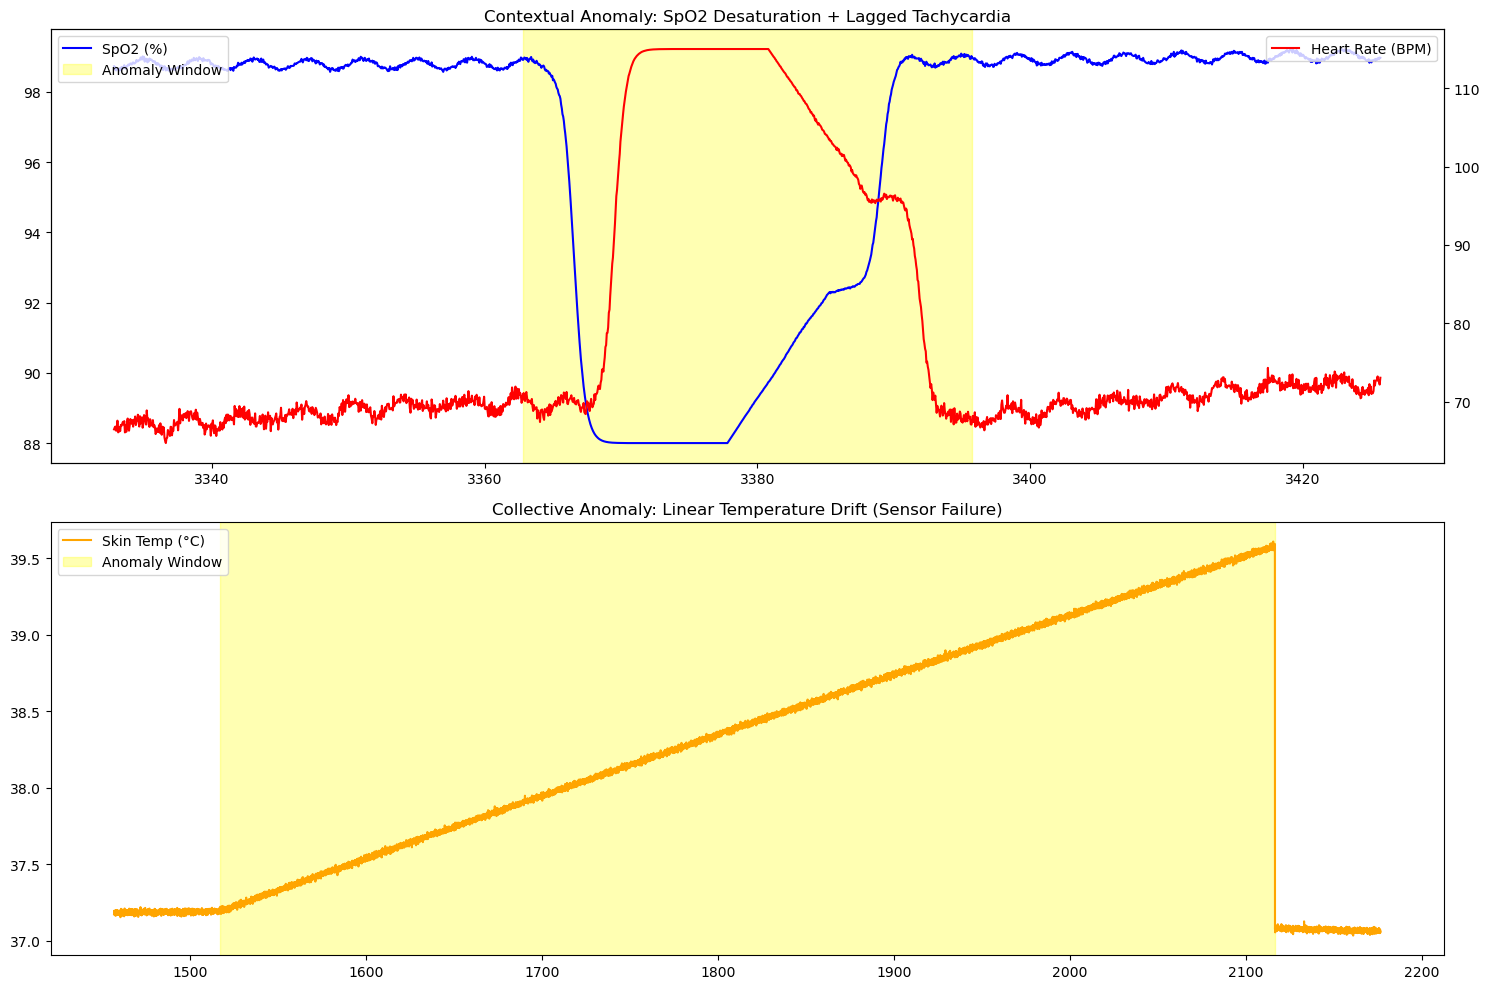

In [17]:
# Load the data generated by your script
df = pd.read_csv('test_anomalous.csv')
fs = 20  # Sample Rate

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# --- Plot 1: Contextual Anomaly (SpO2 & Heart Rate) ---
# Locating the event from the labels (Type 2)
ctx_idx = df[df['anomaly_type'] == 2].index
start, end = ctx_idx[0] - (30*fs), ctx_idx[-1] + (30*fs) # Add 30s padding
subset_ctx = df.iloc[start:end]

ax1 = axes[0]
ax1.plot(subset_ctx.index / fs, subset_ctx['spo2'], color='blue', label='SpO2 (%)')
ax1_hr = ax1.twinx()
ax1_hr.plot(subset_ctx.index / fs, subset_ctx['heart_rate'], color='red', label='Heart Rate (BPM)')
ax1.set_title("Contextual Anomaly: SpO2 Desaturation + Lagged Tachycardia")
ax1.axvspan(ctx_idx[0]/fs, ctx_idx[-1]/fs, color='yellow', alpha=0.3, label='Anomaly Window')
ax1.legend(loc='upper left'); ax1_hr.legend(loc='upper right')

# --- Plot 2: Collective Anomaly (Temperature Drift) ---
col_idx = df[df['anomaly_type'] == 3].index
start_c, end_c = col_idx[0] - (60*fs), col_idx[-1] + (60*fs)
subset_col = df.iloc[start_c:end_c]

ax2 = axes[1]
ax2.plot(subset_col.index / fs, subset_col['temperature'], color='orange', label='Skin Temp (°C)')
ax2.set_title("Collective Anomaly: Linear Temperature Drift (Sensor Failure)")
ax2.axvspan(col_idx[0]/fs, col_idx[-1]/fs, color='yellow', alpha=0.3, label='Anomaly Window')
ax2.legend()

plt.tight_layout()
plt.show()